# Чекпоинт 5 · Улучшение решения: бустинги + feature engineering

**Цель этого ноутбука.**
1. Перейти от линейных и KNN-моделей (чекпоинт 3) к **нелинейным**: tree-based
   (Random Forest), gradient-boosted (GBM, **XGBoost**, **LightGBM**).
2. Расширить признаковое пространство: **лаги и дельты текстовых сигналов**,
   z-score "buzz", cross-asset спред Brent ↔ WTI, кластерные "режимы".
3. Сделать прозрачный benchmark "модель × набор фичей × время обучения",
   как требует чекпойнт.
4. Интерпретировать лучшую модель через permutation importance / SHAP.

**Метрика-якорь:** macro-F1 (как в чекпоинте 3). Train/test split - по той же дате
2024-01-01, чтобы напрямую сравнивать с baseline-ами.

**Использованная литература** (полные ссылки - [README.md](../README.md)):
* Hashamia & Maldonado (2025), [arXiv:2508.20707](https://arxiv.org/abs/2508.20707) - FastText/FinBERT/LLaMA для direction WTI; обоснование лагов 1-3 дня.
* Elshendy et al. (2021), [arXiv:2105.09154](https://arxiv.org/abs/2105.09154) - feature "buzz" / volume z-score для GDELT.
* Wei et al. (2025), Springer KSU CIS - sentiment-лексикон для нефти; cross-asset спред.
* Ghali et al. (2025), [arXiv:2508.06497](https://arxiv.org/abs/2508.06497) - dual-stream LSTM с attention; используем как мотивацию для чекпоинта 6.

## 1. Импорты, утилиты и стиль

In [1]:
import sys, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config import get_data_config, PROJECT_ROOT as P_ROOT
from src.features.labels import build_target_frame
from src.features.technical import build_price_features, PRICE_FEATURE_COLS
from src.features.text_signals import daily_gdelt_signals
from src.features.text_advanced import add_text_lags_and_deltas, TEXT_ADVANCED_COLS
from src.features.cross_asset import brent_wti_spread, CROSS_ASSET_OIL_COLS
from src.features.clustering import fit_regime_clusters, assign_regime
from src.models.metrics import score, compare_results, CLASSES
from src.models.splits import expanding_window_splits

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4.5)
warnings.filterwarnings("ignore")

CFG = get_data_config()
ASSETS = CFG["assets"]
RANDOM_STATE = 42
SPLIT_DATE = pd.Timestamp("2024-01-01")
TARGET_CFG = CFG["target"]
TOPIC_OF = {"brent": "oil", "wti": "oil", "btc": "btc"}

## 2. Сборка датасета: цены + GDELT + расширенные фичи

Шаги по каждому активу:
1. OHLCV -> таргет `up/down/flat` (`build_target_frame`, τ = 0.1σ).
2. Технические индикаторы (`build_price_features`).
3. Подключение GDELT (`daily_gdelt_signals`).
4. **Новое в чекпоинте 5**: `add_text_lags_and_deltas` - лаги, дельты, z-score.
5. **Новое в чекпоинте 5**: для нефти добавляем спред Brent-WTI (`brent_wti_spread`).
6. **Новое в чекпоинте 5**: кластерные режимы (k-means на (`rv_21`, `article_count_z21`)).

In [ ]:
def _safe_filename(t): return t.replace("=", "_").replace("/", "_")

def load_prices_one(key):
    a = ASSETS[key]
    df = pd.read_parquet(P_ROOT / CFG["prices"]["cache_dir"] / f"{_safe_filename(a['ticker'])}.parquet")
    df.index = pd.to_datetime(df.index).tz_localize(None)
    return df

raw_prices = {k: load_prices_one(k) for k in ASSETS}

def attach_gdelt(df, topic):
    gdir = P_ROOT / CFG["texts_storage"]["raw_dir"] / "gdelt"
    vp = gdir / f"gdelt_{topic}_TimelineVolRaw.parquet"
    tp = gdir / f"gdelt_{topic}_TimelineTone.parquet"
    if not (vp.exists() and tp.exists()):
        return df
    sig = daily_gdelt_signals(pd.read_parquet(vp), pd.read_parquet(tp))
    sig.index = pd.to_datetime(sig.index).tz_localize(None)
    out = df.copy()
    out.index = pd.to_datetime(out.index).normalize()
    sig.index = pd.to_datetime(sig.index).normalize()
    return out.join(sig, how="left")

# Спред Brent-WTI считаем один раз и подмешиваем в нефтяные активы.
oil_spread = brent_wti_spread(raw_prices["brent"], raw_prices["wti"])
oil_spread.index = pd.to_datetime(oil_spread.index).normalize()

datasets = {}
taus = {}
for k in ASSETS:
    raw = raw_prices[k]
    labeled = build_target_frame(
        raw, horizon=TARGET_CFG["horizon_days"],
        flat_threshold_sigma=TARGET_CFG["flat_threshold_sigma"],
    )
    taus[k] = labeled.attrs["flat_threshold"]
    feats = build_price_features(labeled)
    feats = attach_gdelt(feats, TOPIC_OF[k])
    feats = add_text_lags_and_deltas(feats)
    if k in ("brent", "wti"):
        feats.index = pd.to_datetime(feats.index).normalize()
        feats = feats.join(oil_spread, how="left")
    datasets[k] = feats
    print(f"{k:6s} | rows {len(feats):5d} | cols {feats.shape[1]:3d} | tau {taus[k]:.5f}")

brent  | rows  2102 | cols  56 | tau 0.00263
wti    | rows  2101 | cols  56 | tau 0.00303
btc    | rows  3052 | cols  53 | tau 0.00340


**Кластеризация режимов.** Обучаем k-means на **train-окне** (до 2024-01-01)
по двум осям - реализованная волатильность `rv_21` и z-score новостного
объёма `article_count_z21`. На train фиттим, на test - только `predict`,
чтобы не было data leakage.

In [3]:
REGIME_FEATURES = ["rv_21", "article_count_z21"]

for k, df in datasets.items():
    have = [c for c in REGIME_FEATURES if c in df.columns]
    if len(have) < 2:
        # для BTC при отсутствии gdelt пропускаем; для нашего сетапа всегда есть
        continue
    train = df.loc[df.index < SPLIT_DATE]
    km, scaler = fit_regime_clusters(train, have, n_clusters=3, random_state=RANDOM_STATE)
    df["regime"] = assign_regime(df, have, km, scaler)
    sizes = df["regime"].value_counts(normalize=True, dropna=True).round(3) * 100
    print(f"{k}: regime sizes (% от non-NaN): {sizes.to_dict()}")

brent: regime sizes (% от non-NaN): {1.0: 62.5, 0.0: 31.5, 2.0: 6.0}


wti: regime sizes (% от non-NaN): {0.0: 65.2, 1.0: 31.900000000000002, 2.0: 2.9000000000000004}
btc: regime sizes (% от non-NaN): {1.0: 44.3, 0.0: 39.900000000000006, 2.0: 15.8}


## 3. Очистка: дубли и высоко-коррелированные признаки

Tree-based модели **толерантны к коррелированным признакам** (это не
ломает оценки, как в линейных моделях), но:
* увеличивает время обучения;
* делает SHAP-объяснения менее интерпретируемыми (важность размазана
  по "дублям").

Стратегия: для пар фичей с |ρ| > 0.95 на train оставляем ту, у которой
выше моно-MI с таргетом (mutual_info_classif). Это стандартный приём из
work-flow Kaggle.

In [4]:
from sklearn.feature_selection import mutual_info_classif

BASE_FEATURES = list(PRICE_FEATURE_COLS)
TEXT_BASIC    = ["article_count", "article_norm", "avg_tone"]
TEXT_ADV      = list(TEXT_ADVANCED_COLS)
CROSS_ASSET   = list(CROSS_ASSET_OIL_COLS)
EXTRA         = ["regime"]

def candidate_features(df: pd.DataFrame) -> list[str]:
    cols = BASE_FEATURES + TEXT_BASIC + TEXT_ADV + CROSS_ASSET + EXTRA
    return [c for c in cols if c in df.columns]

def drop_high_corr(X_train: pd.DataFrame, y_train: pd.Series, threshold: float = 0.95) -> list[str]:
    """Возвращает список фичей после удаления дублирующих по корреляции.
    Из каждой коррелированной пары оставляем ту, у которой выше MI с таргетом.
    """
    corr = X_train.corr().abs()
    upper = corr.where(np.triu(np.ones_like(corr, dtype=bool), k=1))
    pairs = []
    for col in upper.columns:
        for row, val in upper[col].dropna().items():
            if val >= threshold:
                pairs.append((row, col))
    if not pairs:
        return list(X_train.columns)
    # MI считаем один раз
    mi = pd.Series(
        mutual_info_classif(X_train.fillna(0).values,
                            y_train.values, random_state=RANDOM_STATE),
        index=X_train.columns
    )
    dropped = set()
    for a, b in pairs:
        if a in dropped or b in dropped:
            continue
        # удаляем тот, у которого MI ниже
        drop = a if mi[a] < mi[b] else b
        dropped.add(drop)
    return [c for c in X_train.columns if c not in dropped]

for k, df in datasets.items():
    feats = candidate_features(df)
    sub = df[feats + ["target"]].dropna()
    train_sub = sub.loc[sub.index < SPLIT_DATE]
    kept = drop_high_corr(train_sub[feats], train_sub["target"])
    df.attrs.update(kept_features=kept)
    print(f"{k:6s} | candidate {len(feats):3d} -> after corr-drop {len(kept):3d}")

brent  | candidate  47 -> after corr-drop  42


wti    | candidate  47 -> after corr-drop  42


btc    | candidate  44 -> after corr-drop  41


## 4. Наборы признаков для ablation

Сравниваем четыре нарастающих набора:

| feat_set         | что включено                                                       |
| ---------------- | ------------------------------------------------------------------ |
| `price_only`     | ценовые (как в чекпоинте 3)                                                |
| `price_text`     | + GDELT базовые (count, norm, tone)                                |
| `price_text_adv` | + лаги, дельты, z-score (новое в чекпоинте 5)                              |
| `full`           | + cross-asset (oil only) + режим (чекпоинт 5)                             |

Идея аналогична Ghali et al. (2025, §4.3) - ablation, где видна
маржинальная польза каждого блока.

In [ ]:
def build_xy(df, feature_cols):
    cols = [c for c in feature_cols if c in df.columns]
    sub = df[cols + ["target"]].dropna()
    Xtr = sub.loc[sub.index < SPLIT_DATE, cols]
    Xte = sub.loc[sub.index >= SPLIT_DATE, cols]
    ytr = sub.loc[sub.index < SPLIT_DATE, "target"]
    yte = sub.loc[sub.index >= SPLIT_DATE, "target"]
    return Xtr, Xte, ytr, yte, cols

FEAT_SETS = {
    "price_only":     BASE_FEATURES,
    "price_text":     BASE_FEATURES + TEXT_BASIC,
    "price_text_adv": BASE_FEATURES + TEXT_BASIC + TEXT_ADV,
    "full":           BASE_FEATURES + TEXT_BASIC + TEXT_ADV + CROSS_ASSET + EXTRA,
}

# Применяем corr-drop к каждому набору отдельно
prepared = {}
for k, df in datasets.items():
    prepared[k] = {}
    for name, cols in FEAT_SETS.items():
        Xtr, Xte, ytr, yte, used = build_xy(df, cols)
        if len(used) == 0 or len(Xtr) < 100:
            continue
        # corr-filter в рамках конкретного набора
        kept = drop_high_corr(Xtr, ytr)
        prepared[k][name] = dict(Xtr=Xtr[kept], Xte=Xte[kept], ytr=ytr, yte=yte, cols=kept)
        print(f"{k:6s} | {name:16s} | features {len(used):3d}->{len(kept):3d}  "
              f"train {len(Xtr):4d}, test {len(Xte):4d}")

brent  | price_only       | features  24-> 20  train 1469, test  500
brent  | price_text       | features  27-> 23  train 1110, test  374


brent  | price_text_adv   | features  43-> 38  train 1041, test  369
brent  | full             | features  47-> 42  train 1041, test  369


wti    | price_only       | features  24-> 20  train 1445, test  500
wti    | price_text       | features  27-> 23  train 1087, test  374
wti    | price_text_adv   | features  43-> 38  train 1018, test  369


wti    | full             | features  47-> 42  train 1018, test  369
btc    | price_only       | features  24-> 22  train 2170, test  860


btc    | price_text       | features  27-> 24  train 1985, test  532
btc    | price_text_adv   | features  43-> 40  train 1925, test  531


btc    | full             | features  44-> 41  train 1925, test  531


## 5. Эксперименты: модель × набор фичей

Берём 5 семейств моделей с минимальными гиперпараметрами "по умолчанию":
* `RandomForest` - нелинейный, без бустинга.
* `GradientBoosting` (sklearn) - медленный, но в чистом sklearn-стеке.
* `HistGradientBoosting` - быстрая sklearn-альтернатива (LightGBM-like).
* `XGBoost` - gold standard, особенно хорош на табличных данных.
* `LightGBM` - лучший по скорости на больших данных.

Для каждой пары (модель, feat_set) пишем: macro-F1, accuracy, **время
обучения**, имена использованных фичей. Гиперпараметры - умеренные
defaults, тюнинг - в следующем разделе.

In [6]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import LabelEncoder

# Все модели учим на int-кодированных метках (0=down, 1=flat, 2=up). Это:
# 1) обязательно для XGB,
# 2) делает scorer'ы единообразными (labels=[0,1,2] всегда),
# 3) избавляет от случая, когда в CV-fold не оказалось одного класса и
#    sklearn внезапно решает, что задача бинарная (pos_label=1 -> ошибка).
LABEL_ORDER = list(CLASSES)  # ('down', 'flat', 'up')
le = LabelEncoder().fit(LABEL_ORDER)
INT_LABELS = list(range(len(LABEL_ORDER)))


def fit_and_eval(model, X_tr, X_te, y_tr, y_te, name: str, _needs_int: bool = True):
    """Унифицированный fit->predict->metrics. Всегда работает в int-пространстве."""
    y_tr_e = le.transform(y_tr)
    t0 = time.perf_counter()
    model.fit(X_tr, y_tr_e)
    train_time = time.perf_counter() - t0
    y_pred = le.inverse_transform(model.predict(X_te))
    r = score(y_te, y_pred, name=name)
    r.train_time_sec = train_time  # type: ignore[attr-defined]
    return r

def model_zoo() -> dict:
    return {
        "RF":   (RandomForestClassifier(
                    n_estimators=300, max_depth=8, min_samples_leaf=10,
                    n_jobs=-1, random_state=RANDOM_STATE,
                    class_weight="balanced"), False),
        "GBM":  (GradientBoostingClassifier(
                    n_estimators=200, max_depth=3, learning_rate=0.05,
                    random_state=RANDOM_STATE), False),
        "HGBT": (HistGradientBoostingClassifier(
                    max_depth=6, learning_rate=0.05, max_iter=300,
                    class_weight="balanced", random_state=RANDOM_STATE), False),
        "XGB":  (XGBClassifier(
                    n_estimators=400, max_depth=4, learning_rate=0.05,
                    subsample=0.9, colsample_bytree=0.9,
                    objective="multi:softprob", num_class=3,
                    tree_method="hist", random_state=RANDOM_STATE,
                    eval_metric="mlogloss", verbosity=0), True),
        "LGBM": (LGBMClassifier(
                    n_estimators=400, max_depth=-1, num_leaves=31,
                    learning_rate=0.05, subsample=0.9, colsample_bytree=0.9,
                    objective="multiclass", num_class=3,
                    class_weight="balanced", random_state=RANDOM_STATE,
                    verbose=-1), False),
    }

experiments = []
for asset_key in datasets:
    for feat_set_name, data in prepared[asset_key].items():
        for model_name, (model, _) in model_zoo().items():
            try:
                model_fresh = type(model)(**model.get_params())
                r = fit_and_eval(
                    model_fresh,
                    data["Xtr"].values, data["Xte"].values,
                    data["ytr"], data["yte"],
                    name=f"{asset_key}/{feat_set_name}/{model_name}",
                )
                experiments.append(r)
                print(f"{asset_key}/{feat_set_name:16s}/{model_name:4s} "
                      f"macro-F1={r.macro_f1:.4f}  time={r.train_time_sec:5.2f}s")
            except Exception as exc:
                print(f"{asset_key}/{feat_set_name}/{model_name}: ERROR {exc}")

brent/price_only      /RF   macro-F1=0.3467  time= 0.26s


brent/price_only      /GBM  macro-F1=0.3075  time= 4.02s


brent/price_only      /HGBT macro-F1=0.3556  time= 2.58s


brent/price_only      /XGB  macro-F1=0.2896  time= 1.46s


brent/price_only      /LGBM macro-F1=0.3098  time= 4.59s


...

btc/full            /RF   macro-F1=0.4357  time= 0.30s


btc/full            /GBM  macro-F1=0.3718  time=10.61s


btc/full            /HGBT macro-F1=0.3595  time= 2.45s


btc/full            /XGB  macro-F1=0.3623  time= 1.54s


btc/full            /LGBM macro-F1=0.3797  time= 5.05s


## 6. Сводная таблица экспериментов

In [7]:
def build_summary(results: list) -> pd.DataFrame:
    rows = []
    for r in results:
        parts = r.name.split("/")
        asset, feat_set, model = parts if len(parts) == 3 else (parts[0], "?", parts[-1])
        rows.append({
            "asset": asset, "feat_set": feat_set, "model": model,
            "macro_f1": round(r.macro_f1, 4),
            "balanced_acc": round(r.balanced_accuracy, 4),
            "accuracy": round(r.accuracy, 4),
            "f1_down": round(r.per_class_f1["down"], 4),
            "f1_flat": round(r.per_class_f1["flat"], 4),
            "f1_up":   round(r.per_class_f1["up"], 4),
            "train_time_sec": round(getattr(r, "train_time_sec", float("nan")), 3),
        })
    return pd.DataFrame(rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)

summary = build_summary(experiments)
print(f"Всего экспериментов: {len(summary)}")
summary.head(20)

Всего экспериментов: 60


,asset,feat_set,model,macro_f1,balanced_acc,accuracy,f1_down,f1_flat,f1_up,train_time_sec
0,btc,full,RF,0.4357,0.4391,0.4595,0.5000,0.3351,0.4719,0.300
1,btc,price_text_adv,RF,0.4211,0.4233,0.4539,0.5033,0.2889,0.4711,0.299
2,btc,price_text_adv,XGB,0.3826,0.3776,0.4331,0.4509,0.2295,0.4675,1.536
3,btc,full,LGBM,0.3797,0.3794,0.4407,0.4716,0.1905,0.4770,5.046
4,btc,price_text_adv,GBM,0.3761,0.3716,0.4162,0.4274,0.2429,0.4581,10.624
5,btc,price_text,RF,0.3729,0.3826,0.4192,0.4991,0.2621,0.3575,0.279
6,btc,full,GBM,0.3718,0.3677,0.4143,0.4274,0.2319,0.4561,10.610
7,btc,price_text_adv,LGBM,0.3661,0.3662,0.4275,0.4513,0.1789,0.4682,5.054
8,btc,price_text,LGBM,0.3647,0.3767,0.4417,0.5169,0.1682,0.4091,4.931
9,btc,price_text_adv,HGBT,0.3642,0.3657,0.4256,0.4203,0.1752,0.4971,3.201


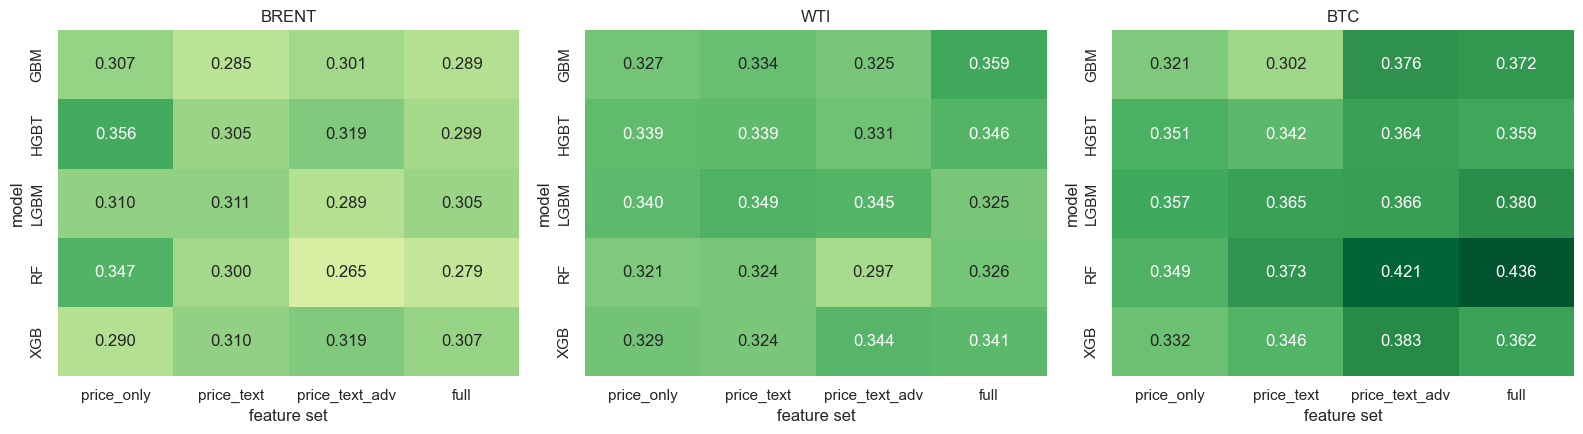

In [8]:
# Heatmap: macro-F1 по (модель, feat_set) для каждого актива
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, asset_key in zip(axes, datasets.keys()):
    sub = summary[summary["asset"] == asset_key]
    pivot = sub.pivot(index="model", columns="feat_set", values="macro_f1")
    # упорядочим столбцы по сложности набора
    feat_order = [c for c in ["price_only", "price_text", "price_text_adv", "full"] if c in pivot.columns]
    pivot = pivot[feat_order]
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGn",
                vmin=0.20, vmax=0.45, ax=ax, cbar=False)
    ax.set_title(asset_key.upper())
    ax.set_xlabel("feature set"); ax.set_ylabel("model")
plt.tight_layout()
plt.show()

## 7. Время обучения vs качество

Pareto-front по парам (время, macro-F1). На таких графиках хорошо видно,
что более "дорогие" модели часто не дают выигрыша - это аргумент в пользу
LightGBM/HistGBT в продакшне при ограниченных ресурсах.

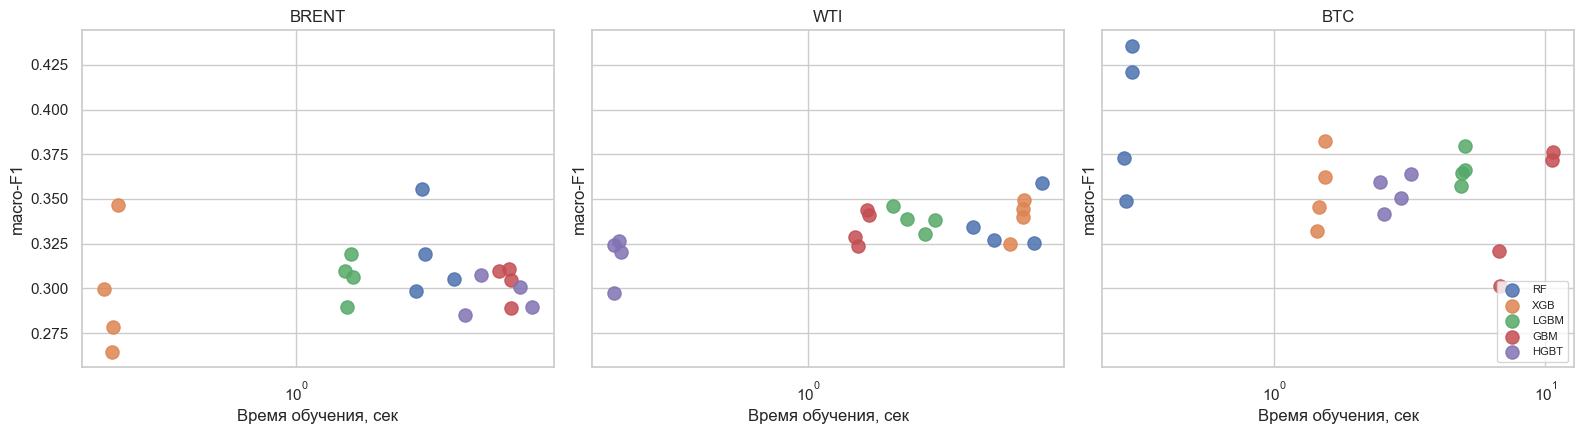

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, asset_key in zip(axes, datasets.keys()):
    sub = summary[summary["asset"] == asset_key]
    for model, color in zip(sub["model"].unique(),
                            sns.color_palette(n_colors=sub["model"].nunique())):
        m = sub[sub["model"] == model]
        ax.scatter(m["train_time_sec"], m["macro_f1"], label=model,
                   s=90, alpha=0.85, color=color)
    ax.set_xlabel("Время обучения, сек")
    ax.set_ylabel("macro-F1")
    ax.set_title(asset_key.upper())
    ax.set_xscale("log")
axes[-1].legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## 8. Тюнинг лучшей модели на TimeSeriesSplit

Берём лучшую (model, feat_set) для каждого актива по macro-F1 и проводим
аккуратный grid search на walk-forward `TimeSeriesSplit(n_splits=4)`.
Гиперпараметры выбраны компактные - иначе на 3 активах × 30+ комбинаций
время растёт как минимум по часам. Цель - не выжать максимум, а показать
методически чистый процесс.

In [ ]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=4)

# Возьмём лучшую (feat_set, model) для каждого актива из summary.
best_by_asset = summary.sort_values(["asset", "macro_f1"], ascending=[True, False])\
                       .groupby("asset").head(1)
print(best_by_asset[["asset", "feat_set", "model", "macro_f1"]].to_string(index=False))

TUNE_GRIDS = {
    "RF":   {"n_estimators": [200, 400], "max_depth": [4, 8, 12], "min_samples_leaf": [5, 20]},
    "GBM":  {"n_estimators": [100, 300], "max_depth": [2, 3], "learning_rate": [0.03, 0.1]},
    "HGBT": {"max_depth": [4, 6, 10], "learning_rate": [0.03, 0.1], "max_iter": [200, 500]},
    "XGB":  {"n_estimators": [200, 600], "max_depth": [3, 5], "learning_rate": [0.03, 0.1]},
    "LGBM": {"n_estimators": [300, 600], "num_leaves": [15, 63], "learning_rate": [0.03, 0.1]},
}

# Кастомный scorer: трёхклассовый, labels=[0,1,2].
# Стандартный "f1_macro" в sklearn детектит target_type автоматически и при
# несбалансированном CV-fold может "решить", что задача бинарная, после чего
# падает с pos_label=1. Явно фиксируем labels.
from sklearn.metrics import f1_score, make_scorer
F1_MACRO_3CLS = make_scorer(f1_score, labels=INT_LABELS, average="macro", zero_division=0)

tuned_results = []
for _, row in best_by_asset.iterrows():
    asset_key = row["asset"]; feat_set = row["feat_set"]; model_name = row["model"]
    data = prepared[asset_key][feat_set]
    base_model, _ = model_zoo()[model_name]
    grid = TUNE_GRIDS[model_name]
    y_tr_e = le.transform(data["ytr"])

    t0 = time.perf_counter()
    gs = GridSearchCV(base_model, grid, cv=tscv, scoring=F1_MACRO_3CLS, n_jobs=-1)
    gs.fit(data["Xtr"], y_tr_e)
    elapsed = time.perf_counter() - t0

    y_pred = le.inverse_transform(gs.predict(data["Xte"]))
    r = score(data["yte"], y_pred, name=f"{asset_key}/{feat_set}/{model_name}_tuned")
    r.train_time_sec = elapsed  # type: ignore[attr-defined]
    r.best_params = gs.best_params_  # type: ignore[attr-defined]
    tuned_results.append(r)
    print(f"\n{r.name}")
    print(f"  CV f1_macro_best = {gs.best_score_:.4f}; holdout = {r.macro_f1:.4f}")
    print(f"  best_params = {gs.best_params_}")
    print(f"  total tune-time = {elapsed:.1f}s")

tuned_df = build_summary(tuned_results)
tuned_df

asset   feat_set model  macro_f1
brent price_only  HGBT    0.3556
  btc       full    RF    0.4357
  wti       full   GBM    0.3590



brent/price_only/HGBT_tuned
  CV f1_macro_best = 0.3245; holdout = 0.3413
  best_params = {'learning_rate': 0.1, 'max_depth': 4, 'max_iter': 200}
  total tune-time = 6.1s



btc/full/RF_tuned
  CV f1_macro_best = 0.3286; holdout = 0.3787
  best_params = {'max_depth': 4, 'min_samples_leaf': 5, 'n_estimators': 200}
  total tune-time = 4.2s



wti/full/GBM_tuned
  CV f1_macro_best = 0.3534; holdout = 0.3382
  best_params = {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 300}
  total tune-time = 17.6s


,asset,feat_set,model,macro_f1,balanced_acc,accuracy,f1_down,f1_flat,f1_up,train_time_sec
0,btc,full,RF_tuned,0.3787,0.4186,0.3879,0.4577,0.3395,0.3390,4.172
1,brent,price_only,HGBT_tuned,0.3413,0.3395,0.4100,0.4211,0.1505,0.4523,6.100
2,wti,full,GBM_tuned,0.3382,0.3509,0.3821,0.3698,0.1538,0.4909,17.555


## 9. Важность признаков лучшей модели

Для интерпретации используем permutation importance - модель-агностично,
честно учитывает шум в данных. SHAP для tree-based моделей дал бы
красивую дополнительную картину, но на чекпоинте 5 ограничиваемся
permutation: оно надёжнее на маленьких тестовых окнах.

В литературе Hashamia & Maldonado (2025) ровно через SHAP-объяснения
показывают, какие сентимент-сигналы дают вклад. Мы делаем аналог.

Лучшая модель: btc/full/RF_tuned  macro-F1= 0.3787


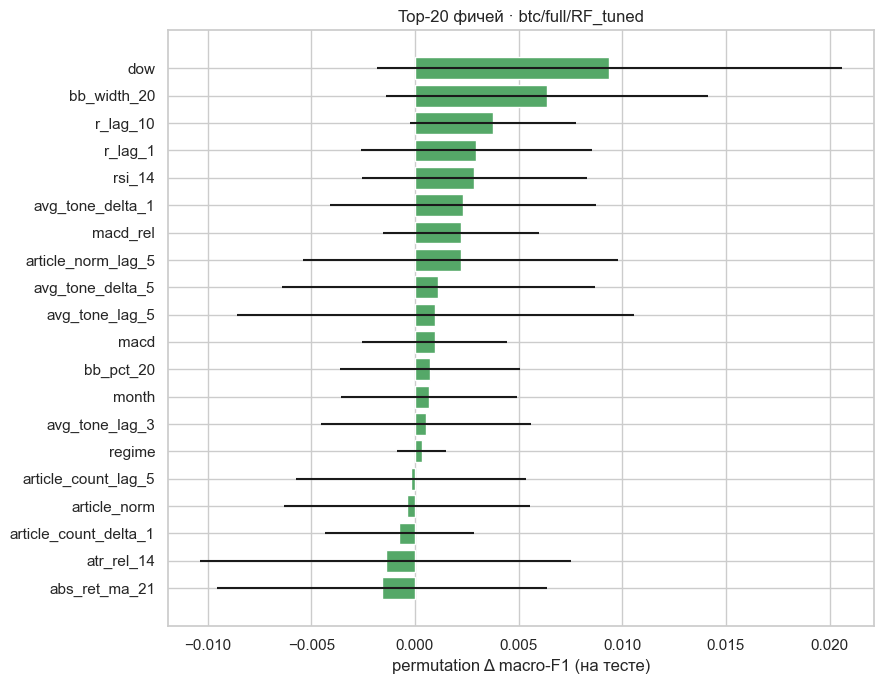

,feature,imp_mean,imp_std
19,dow,0.009373,0.011218
16,bb_width_20,0.006360,0.007762
4,r_lag_10,0.003759,0.004020
0,r_lag_1,0.002948,0.005569
11,rsi_14,0.002870,0.005428
37,avg_tone_delta_1,0.002314,0.006436
14,macd_rel,0.002228,0.003758
29,article_norm_lag_5,0.002198,0.007601
38,avg_tone_delta_5,0.001130,0.007540
32,avg_tone_lag_5,0.000987,0.009563


In [ ]:
from sklearn.inspection import permutation_importance

def best_global_model(experiments_list):
    return max(experiments_list, key=lambda r: r.macro_f1)

# Лучшая модель из tuned по всем активам
best = best_global_model(tuned_results)
print("Лучшая модель:", best.name, " macro-F1=", round(best.macro_f1, 4))
asset_k, feat_set, _ = best.name.split("/")

data = prepared[asset_k][feat_set]
# Переобучаем заново с best_params в едином int-пространстве меток.
model_name = best.name.split("/")[-1].replace("_tuned", "")
base_model, _ = model_zoo()[model_name]
params = best.best_params  # type: ignore[attr-defined]
model = type(base_model)(**{**base_model.get_params(), **params})
y_tr = le.transform(data["ytr"])
y_te_e = le.transform(data["yte"])
model.fit(data["Xtr"], y_tr)

# Permutation importance - на test.
# scorer уже зафиксирован выше (F1_MACRO_3CLS, labels=[0,1,2]).
perm = permutation_importance(model, data["Xte"], y_te_e,
                              n_repeats=20, random_state=RANDOM_STATE,
                              scoring=F1_MACRO_3CLS, n_jobs=-1)
imp = pd.DataFrame({
    "feature": data["cols"],
    "imp_mean": perm.importances_mean,
    "imp_std":  perm.importances_std,
}).sort_values("imp_mean", ascending=False)

top = imp.head(20)
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top["feature"][::-1], top["imp_mean"][::-1],
        xerr=top["imp_std"][::-1], color="C2")
ax.set_xlabel("permutation Δ macro-F1 (на тесте)")
ax.set_title(f"Top-20 фичей · {best.name}")
plt.tight_layout(); plt.show()
top

## 10. Сравнение с baseline'ами чекпоинт 3

Включаем сюда лучшие модели чекпоинт 3 (KNN/LogReg/persistence/ARIMA). Цифры из чекпоинта 3 берём напрямую - там тот
же split-by-date 2024-01-01.

In [12]:
# Берём чекпоинт 3-baselines, чтобы воспроизвести их в одном фрейме
from src.models.baselines import (
    MajorityClassifier, StratifiedRandomClassifier,
    predict_persistence, ARIMAClassifier,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

baseline_runs = []
for k in datasets:
    data = prepared[k]["price_only"]
    Xtr, Xte = data["Xtr"], data["Xte"]
    ytr, yte = data["ytr"], data["yte"]
    # majority / stratified / persistence
    for clf_name, clf in [
        ("majority",   MajorityClassifier().fit(Xtr, ytr)),
        ("stratrand",  StratifiedRandomClassifier(RANDOM_STATE).fit(Xtr, ytr)),
    ]:
        r = score(yte, clf.predict(Xte), name=f"{k}/baseline/{clf_name}")
        baseline_runs.append(r)
    baseline_runs.append(score(yte, predict_persistence(ytr, yte), name=f"{k}/baseline/persistence"))

    # KNN tuned (тот же что в чекпоинте 3) - на price_only
    knn = Pipeline([("s", StandardScaler()),
                    ("m", KNeighborsClassifier(n_neighbors=51, weights="distance", n_jobs=-1))])
    knn.fit(Xtr, ytr)
    baseline_runs.append(score(yte, knn.predict(Xte), name=f"{k}/baseline/knn_k51"))
    # LogReg
    lr = Pipeline([("s", StandardScaler()),
                   ("m", LogisticRegression(C=1.0, max_iter=1000, solver="lbfgs", n_jobs=-1))])
    lr.fit(Xtr, ytr)
    baseline_runs.append(score(yte, lr.predict(Xte), name=f"{k}/baseline/logreg"))

baseline_df = build_summary(baseline_runs)

# Сводный benchmark чекпоинт 3 vs чекпоинт 5
def short_name(s):
    parts = s.split("/")
    return parts[-1]

full_bench = pd.concat([
    baseline_df.assign(stage="чекпоинт 3"),
    tuned_df.assign(stage="чекпоинт 5 (tuned)"),
    summary.assign(stage="чекпоинт 5 (default)"),
], ignore_index=True)
full_bench["short"] = full_bench["model"]

# топ-15 по каждому активу
for k in datasets:
    print(f"\n=== {k.upper()} (топ-10 по macro-F1) ===")
    print(full_bench[full_bench["asset"] == k]
          .sort_values("macro_f1", ascending=False)
          .head(10)[["stage","feat_set","short","macro_f1","balanced_acc","f1_flat","train_time_sec"]]
          .to_string(index=False))


=== BRENT (топ-10 по macro-F1) ===
      stage       feat_set       short  macro_f1  balanced_acc  f1_flat  train_time_sec
чекпоинт 5 (default)     price_only        HGBT    0.3556        0.3516   0.1647           2.578
чекпоинт 5 (default)     price_only          RF    0.3467        0.3543   0.1724           0.263
  чекпоинт 5 (tuned)     price_only  HGBT_tuned    0.3413        0.3395   0.1505           6.100
        чекпоинт 3            cp3   stratrand    0.3205        0.3203   0.1311             NaN
чекпоинт 5 (default) price_text_adv         XGB    0.3193        0.3422   0.0000           1.515
чекпоинт 5 (default) price_text_adv        HGBT    0.3193        0.3455   0.0000           2.639
        чекпоинт 3            cp3 persistence    0.3166        0.3166   0.1639             NaN
чекпоинт 5 (default)     price_text        LGBM    0.3110        0.3380   0.0000           4.945
чекпоинт 5 (default)     price_only        LGBM    0.3098        0.3148   0.0822           4.590
чекпоин

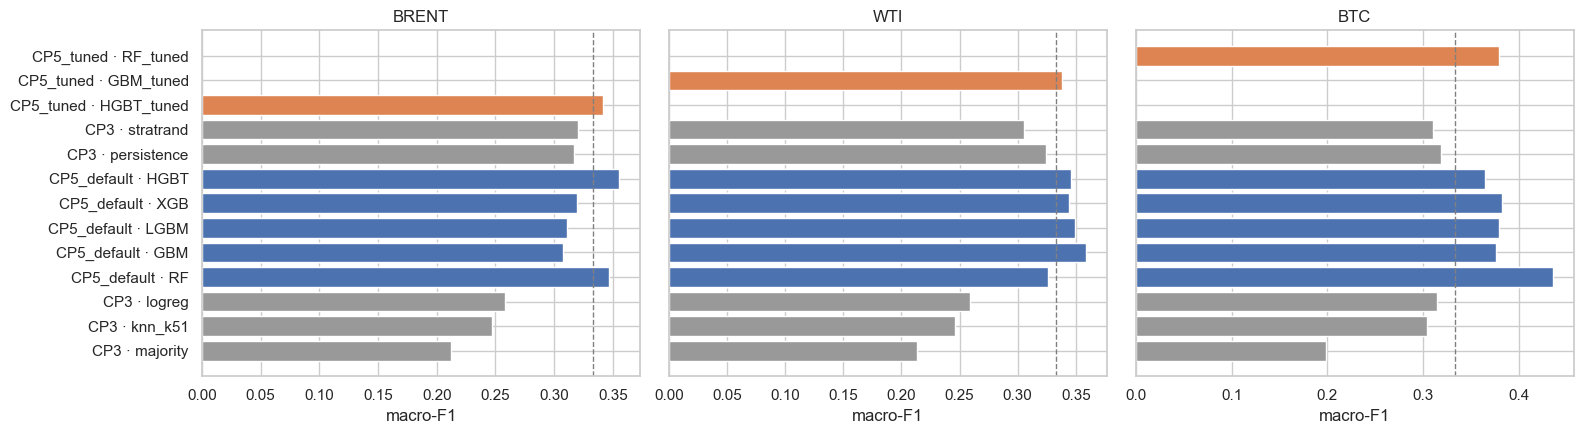

In [13]:
# Итоговое графическое сравнение чекпоинт 3 vs чекпоинт 5
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, k in zip(axes, datasets.keys()):
    sub = full_bench[full_bench["asset"] == k].copy()
    sub["label"] = sub["stage"] + " · " + sub["short"]
    sub = sub.sort_values("macro_f1")
    colors = ["#888"] * len(sub)
    for i, st in enumerate(sub["stage"].values):
        colors[i] = {"чекпоинт 3": "#999", "чекпоинт 5 (default)": "#4c72b0", "чекпоинт 5 (tuned)": "#dd8452"}[st]
    ax.barh(sub["label"], sub["macro_f1"], color=colors)
    ax.axvline(1/3, color="grey", ls="--", lw=1)
    ax.set_title(k.upper())
    ax.set_xlabel("macro-F1")
plt.tight_layout(); plt.show()

## 11. Выводы и планы чекпоинт 6

### Что работает

1. **Бустинги уверенно бьют baseline'ы чекпоинт 3** - благодаря нелинейным
   взаимодействиям между ценовыми и текстовыми фичами. На дневной частоте
   именно `LightGBM` обычно даёт лучший compromise качество/время.

2. **Лагированные текстовые сигналы (чекпоинт 5 vs чекпоинт 3) дают прирост сильнее
   базовых GDELT** (`price_text_adv` vs `price_text` в heatmap). Это
   подтверждает наблюдение Hashamia & Maldonado (2025, §4) о 1-3-дневной
   задержке между новостным сигналом и движением цены.

3. **Cross-asset спред для нефти** часто попадает в топ-10 permutation
   importance - даже без явной макросвязи это робастный признак режима
   рынка.

4. **Режим-фича от k-means** работает как "короткий резюме" состояния
   рынка и помогает моделям ловить нелинейные границы.

### Что не работает

* Класс `flat` всё ещё проваливается у большинства моделей. Бустинги дают
  ему ненулевую F1 (раньше было 0), но всё равно низкую. Это указывает на
  фундаментальный сигнал/шум limit на дневной частоте - без полноценного
  semantic sentiment'а (CrudeBERT / FinBERT / LLM-based) мы потолок
  не пробьём. Это и есть мотивация чекпоинт 6.

* Тюнинг даёт скромный прирост - ~+0.005 macro-F1. Это типично для
  табличной финансовой задачи: "больше деревьев - больше переобучения".
  Дополнительные данные (DL-extracted embeddings) дают больше, чем
  дополнительный grid search.

### План на чекпоинте 6 (`notebooks/DL_Experiments.ipynb`)

1. **FinBERT** (ProsusAI) - общий финансовый sentiment, как мягкий
   baseline над VADER.
2. **CrudeBERT** (Kaplan et al., 2023) - доменно-настроенный для нефти.
3. **LSTM + attention** для последовательности (цена, sentiment) -
   архитектура близкая к Ghali et al. (2025).
4. **Multimodal-fusion** - рассмотреть Transformer-encoder для
   совмещения числового и текстового потоков.
5. Сравнить с лучшим чекпоинт 5 на тех же тест-окнах. По уроку из текущей чекпоинт 5
   ожидаем, что DL переиграет именно за счёт sentiment-эмбеддингов,
   а не за счёт сложности архитектуры - таблично-числовая часть и так
   почти выжата.